# SATAY-ViT GPU Training Pipeline
This notebook trains the ME-ViT Reasoner on your local NVIDIA GPU using the **offline-preprocessed** COCO-Tasks dataset.

In [3]:
import os, sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

# --- Configuration ---
PIPELINE_DIR = "e:/DVcon/DVcon/Pipelines/satay_vit"
DATA_ROOT    = "e:/DVcon/DVcon/Data_Preprocessed"
WEIGHTS_DIR  = os.path.join(PIPELINE_DIR, "weights")
BATCH_SIZE   = 16
EPOCHS       = 20
LR           = 1e-4

# Add pipeline directory to path so local modules resolve correctly
if PIPELINE_DIR not in sys.path:
    sys.path.insert(0, PIPELINE_DIR)

os.makedirs(WEIGHTS_DIR, exist_ok=True)

# CUDA check
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

CUDA Available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Using device: cuda


## 0. Verify Preprocessed Data Exists

In [4]:
train_manifest = os.path.join(DATA_ROOT, 'train', 'samples.json')
test_manifest  = os.path.join(DATA_ROOT, 'test',  'samples.json')

if not os.path.exists(train_manifest) or not os.path.exists(test_manifest):
    print("Preprocessed data not found! Running preprocess_dataset.py now...")
    import subprocess
    result = subprocess.run(
        [sys.executable, os.path.join(PIPELINE_DIR, 'preprocess_dataset.py')],
        capture_output=True, text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        print("ERROR:", result.stderr)
        raise RuntimeError("Preprocessing failed. Check the error above.")
else:
    import json
    with open(train_manifest) as f: tr = json.load(f)
    with open(test_manifest)  as f: te = json.load(f)
    print(f"Preprocessed data ready!")
    print(f"  Train samples : {len(tr):,}")
    print(f"  Test  samples : {len(te):,}")

Preprocessed data ready!
  Train samples : 100,800
  Test  samples : 12,600


## 1. Load Dataset & Build DataLoaders

In [5]:
from utils.data_loader import COCOTasksDataset, custom_collate

train_dataset = COCOTasksDataset(DATA_ROOT, split='train')
val_dataset   = COCOTasksDataset(DATA_ROOT, split='test')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          persistent_workers=True,
                          num_workers=4, pin_memory=True, collate_fn=custom_collate)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          persistent_workers=True,
                          num_workers=4, pin_memory=True, collate_fn=custom_collate)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Loaded 100800 PREPROCESSED samples for train split.
Loaded 12600 PREPROCESSED samples for test split.
Train batches: 6300 | Val batches: 788


## 2. Initialize Model, Optimizer & Loss

In [6]:
from utils.model import MEViTReasoner

model     = MEViTReasoner().to(device)
criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ME-ViT Reasoner | Trainable parameters: {total_params:,}")

ME-ViT Reasoner | Trainable parameters: 7,327,744


## 3. Training Loop (CUDA Accelerated)

In [7]:
import os
import json
import torch

# --- Setup ---
best_val_loss = float('inf')
train_history = []
val_history   = []

START_EPOCH = 14
latest_ckpt_path = os.path.join(WEIGHTS_DIR, 'mevit_latest.pt')
hist_path = os.path.join(WEIGHTS_DIR, 'mevit_history.json')

# --- Resume logic ---
if os.path.exists(latest_ckpt_path):
    print(f"Resuming from {latest_ckpt_path}")
    checkpoint = torch.load(latest_ckpt_path, map_location=device)

    model.load_state_dict(checkpoint['state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    START_EPOCH   = checkpoint['epoch']
    best_val_loss = checkpoint.get('best_val_loss', float('inf'))

    if os.path.exists(hist_path):
        with open(hist_path, 'r') as f:
            hist = json.load(f)
            train_history = hist.get('train', [])
            val_history   = hist.get('val', [])

# --- Training loop ---
for epoch in range(START_EPOCH, EPOCHS):

    # --- Train ---
    model.train()
    train_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for batch in pbar:
        imgs     = batch['image'].to(device)
        tasks    = batch['task_id'].to(device)
        gt_hmaps = batch['heatmap'].to(device)

        optimizer.zero_grad()
        pred_hmaps = model(imgs, tasks)
        loss = criterion(pred_hmaps, gt_hmaps)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train = train_loss / len(train_loader)

    # --- Validate ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]"):
            imgs     = batch['image'].to(device)
            tasks    = batch['task_id'].to(device)
            gt_hmaps = batch['heatmap'].to(device)

            pred_hmaps = model(imgs, tasks)
            val_loss += criterion(pred_hmaps, gt_hmaps).item()

    avg_val = val_loss / len(val_loader)

    train_history.append(avg_train)
    val_history.append(avg_val)

    print(f"Epoch {epoch+1:>2} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

    # --- Save BEST model ---
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        best_path = os.path.join(WEIGHTS_DIR, 'mevit_best.pt')
        torch.save({
            'epoch': epoch + 1,
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'best_val_loss': best_val_loss
        }, best_path)
        print(f"  ==> Saved BEST model -> {best_path}")

    # --- Save LATEST (for resume) ---
    torch.save({
        'epoch': epoch + 1,
        'state_dict': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'best_val_loss': best_val_loss
    }, latest_ckpt_path)

    # --- Save PER-EPOCH checkpoint ---
    epoch_path = os.path.join(WEIGHTS_DIR, f'mevit_epoch_{epoch+1}.pt')
    torch.save({
        'epoch': epoch + 1,
        'state_dict': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'best_val_loss': best_val_loss
    }, epoch_path)

    # --- Save history ---
    with open(hist_path, 'w') as f:
        json.dump({
            'train': train_history,
            'val': val_history
        }, f)

print(f"\nBest Validation Loss: {best_val_loss:.4f}")

Resuming from e:/DVcon/DVcon/Pipelines/satay_vit\weights\mevit_latest.pt


Epoch 15/20 [Train]:   0%|          | 0/6300 [00:00<?, ?it/s]

Epoch 15/20 [Valid]:   0%|          | 0/788 [00:00<?, ?it/s]

Epoch 15 | Train Loss: 0.1563 | Val Loss: 0.1556


Epoch 16/20 [Train]:   0%|          | 0/6300 [00:00<?, ?it/s]

...

Epoch 19/20 [Valid]:   0%|          | 0/788 [00:00<?, ?it/s]

Epoch 19 | Train Loss: 0.1524 | Val Loss: 0.1574


Epoch 20/20 [Train]:   0%|          | 0/6300 [00:00<?, ?it/s]

Epoch 20/20 [Valid]:   0%|          | 0/788 [00:00<?, ?it/s]

Epoch 20 | Train Loss: 0.1519 | Val Loss: 0.1570

Best Validation Loss: 0.1547


## 4. Training Curve (Overfit/Underfit Analysis)

Loss curve saved to: e:/DVcon/DVcon/Pipelines/satay_vit\weights\loss_curve.png


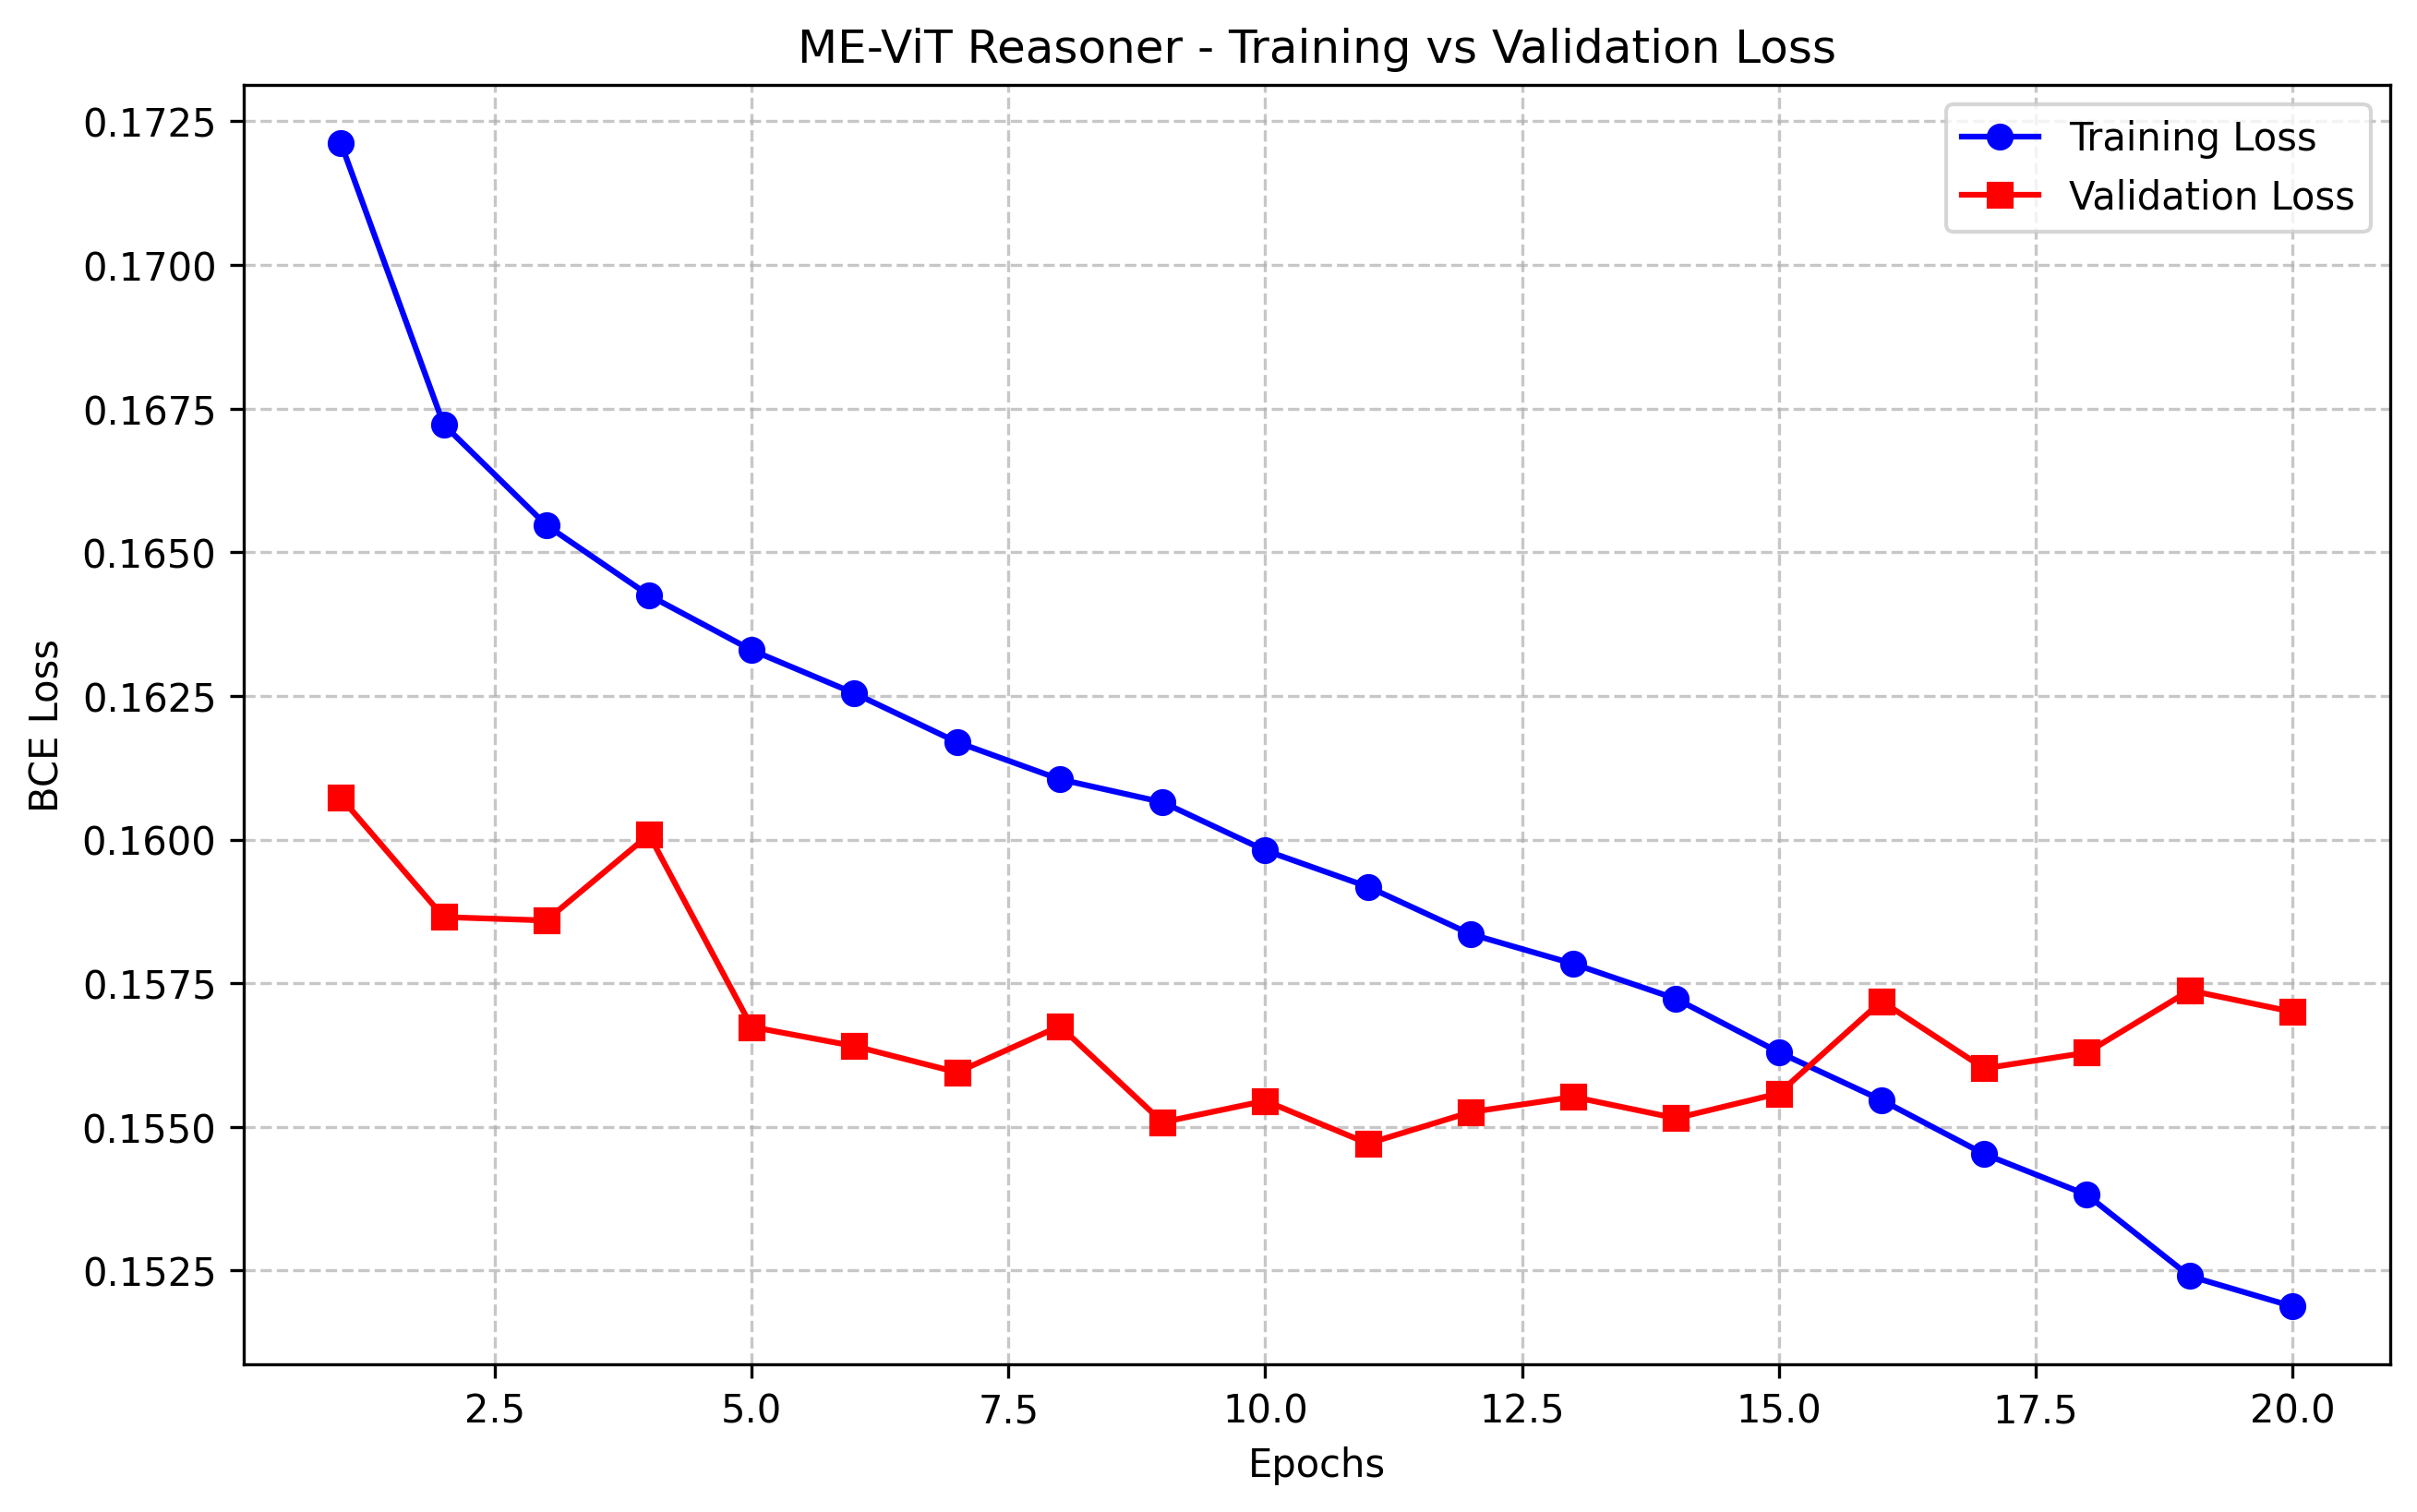

In [8]:
from utils.plot_metrics import plot_training_losses
from IPython.display import display, Image

plot_path = plot_training_losses(train_history, val_history, save_dir=WEIGHTS_DIR)
print(f"Loss curve saved to: {plot_path}")
display(Image(filename=plot_path))

## 5. Evaluation: Top-1 Task-Aware Fusion Accuracy
Loads the best saved checkpoint, runs full YOLO + ME-ViT late-fusion over the test set, and reports the percentage of images where the highest-scoring fused box overlaps a human-preferred ground-truth box at IoU > 0.5.

In [12]:
from utils.evaluate import evaluate_best_model

accuracy = evaluate_best_model(
    data_root    = DATA_ROOT,
    weights_path = os.path.join(WEIGHTS_DIR, 'mevit_best.pt'),
    device       = device
)

Loading Models...


RuntimeError: Error(s) in loading state_dict for MEViTReasoner:
	Missing key(s) in state_dict: "pos_embed", "patch_embed.weight", "patch_embed.bias", "task_embedding.weight", "transformer.layers.0.self_attn.in_proj_weight", "transformer.layers.0.self_attn.in_proj_bias", "transformer.layers.0.self_attn.out_proj.weight", "transformer.layers.0.self_attn.out_proj.bias", "transformer.layers.0.linear1.weight", "transformer.layers.0.linear1.bias", "transformer.layers.0.linear2.weight", "transformer.layers.0.linear2.bias", "transformer.layers.0.norm1.weight", "transformer.layers.0.norm1.bias", "transformer.layers.0.norm2.weight", "transformer.layers.0.norm2.bias", "transformer.layers.1.self_attn.in_proj_weight", "transformer.layers.1.self_attn.in_proj_bias", "transformer.layers.1.self_attn.out_proj.weight", "transformer.layers.1.self_attn.out_proj.bias", "transformer.layers.1.linear1.weight", "transformer.layers.1.linear1.bias", "transformer.layers.1.linear2.weight", "transformer.layers.1.line